**Laboratory Report**  
General Physics Laboratory 2  
O17e - Diffraction  

**Semester:** Summer Semester 2026  
**Date of experiment:** April 22, 2026  

**Group Members**  
Reza Mansurnezhad 3764407  (50%)  
Avinoam Braverman 3793994  (50%)  
  
---


# Task 0: Fourier Transform of single and double slit functions

#### A. Objective
To compare analytic calculation and numeric computation of Fourier Transforms with the Fraunhofer diffraction-patterns for the single and double slit functions.

#### B. Theory
##### 1. Fourier Transforms
Let $A_i(x)$ denote the slit functions for $i$ slits.  
\begin{align*}
    A_1(x) &= \left\{
    \begin{array}{c|c}
    1 & |x| < b/2 \\
    0 & -
    \end{array} \right.\\
    A_2(x) &= A_1(x + g/2) + A_1(x - g/2)
\end{align*}

Let us calculate the Fourier Transforms.

\begin{align*}
    \mathcal{F}(A_1) &= F_1(k)\\
    &= \int_{-\infty}^{+\infty} A_1(x) e^{-2\pi ikx} dx\\
    &= \int_{-b/2}^{+b/2} e^{-2\pi ikx} dx\\
    &= \frac{e^{-2\pi ikb/2}-e^{2\pi ikb/2}}{-2\pi ik}\\
    &= \frac{-2i \sin (2\pi kb/2)}{-2\pi ik}\\
    &= b \frac{\sin (2\pi kb/2)}{\pi kb}\\
    &= b\,\text{sinc} (\pi kb)\\
    \mathcal{F}(A_2) &= F_2(k)\\
    &= \int_{-\infty}^{+\infty} A_2(x) e^{-2\pi ikx} dx\\
    &= \int_{g/2-b/2}^{g/2+b/2} e^{-2\pi ikx} dx + \int_{-g/2-b/2}^{-g/2+b/2} e^{-2\pi ikx} dx\\
    &= e^{-2\pi ik(-g/2)}\int_{-b/2}^{+b/2} e^{-2\pi ikx} dx + e^{-2\pi ik(g/2)}\int_{-b/2}^{+b/2} e^{-2\pi ikx} dx\\
    &= (e^{-2\pi ik(-g/2)}+e^{-2\pi ik(-g/2)}) F_1(k)\\
    &= a\,\cos(\pi kg)\,\text{sinc} (\pi kb)\\
\end{align*}

Note: the exercise had a factor of $2 \pi$ for $k$, so we've chosen to be consistent with this. Technically this makes $k$ not a wave number, but a spatial frequency.  

Recall that we're interested only in positions on the screen. We take the small angle approximation.

\begin{align*}
    k_x &= k_0 \sin \theta\\
    k_0 &= \frac{1}{\lambda}\\
    x &= L \tan \theta\\
    k_x &\approx \frac{x}{\lambda L}\\
\end{align*}

##### 2. Fraunhofer Diffraction
Fraunhofer relates intensity with the Fourier Transform.

\begin{align*}
    I(k) &= I_0 |F(k)|^2\\
    I_1(k)&= I_0 b^2\,\text{sinc}^2 (\pi kb)\\
    I_2(k)&= I_0 b^2\,\cos^2(\pi kg)\,\text{sinc}^2 (\pi kb)\\
\end{align*}

It is clear that $I_2$ is not simply the sum of two translations of $I_1$.

##### 3. Inverse Fourier Transforms

Calculated FFT in python. We get an approximate rectangle (Gibbs phenomenon), and a triangle, respectively.


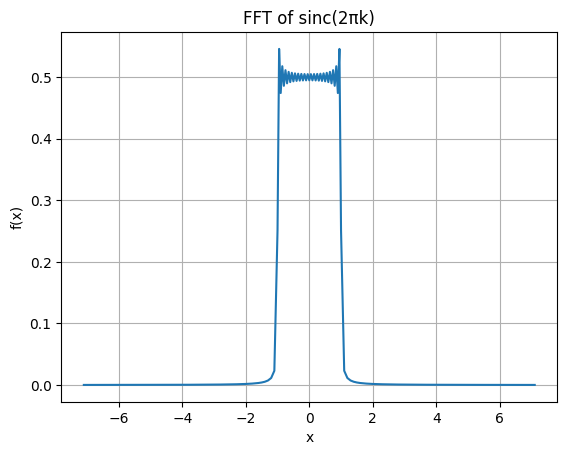

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# number of points
N = 4096

# k-axis (frequency domain)
k = np.linspace(-10, 10, N)

# define sinc(2πk)
F_k = np.sinc(2 * k)  # numpy sinc = sin(pi x)/(pi x)

# FFT → go to x-space
f_x = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(F_k)))

# corresponding x-axis
dk = k[1] - k[0]
x = np.fft.fftshift(np.fft.fftfreq(N, d=dk))

# normalize (important!)
f_x = f_x * dk

# define cutoff for nice graph
y=np.real(f_x)
mask = (y > 1e-4)

# plot
plt.plot(x[mask], y[mask])
plt.title("FFT of sinc(2πk)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

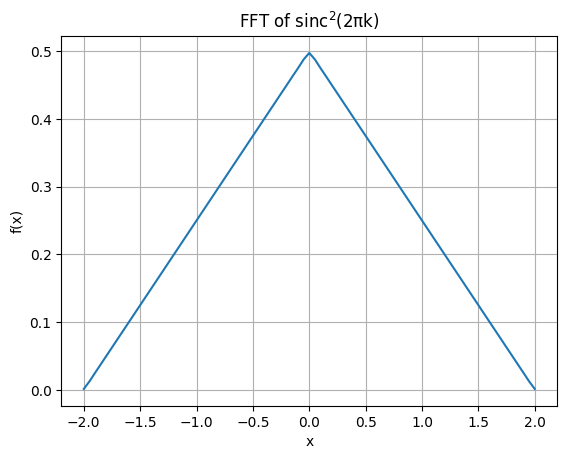

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# number of points
N = 4096

# k-axis (frequency domain)
k = np.linspace(-10, 10, N)

# define sinc(2πk) ** 2
F_k = np.sinc(2 * k) ** 2  # numpy sinc = sin(pi x)/(pi x)

# FFT → go to x-space
f_x = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(F_k)))

# corresponding x-axis
dk = k[1] - k[0]
x = np.fft.fftshift(np.fft.fftfreq(N, d=dk))

# normalize (important!)
f_x = f_x * dk

# define cutoff for nice graph
y=np.real(f_x)
mask = (y > 1e-4)

# plot
plt.plot(x[mask], y[mask])
plt.title(r"FFT of sinc$^2$(2πk)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()